# Régression  polynomiale -> à finir le 1er jour





https://data36.com/polynomial-regression-python-scikit-learn/

https://medium.com/@shuv.sdr/polynomial-regression-in-python-58198fb0973f

https://medium.com/@ckekula/polynomial-regression-in-machine-learning-a-mathematical-guide-693648746d84



La régression polynomiale est un type d'analyse de régression dans lequel la relation entre la variable indépendante x et la variable dépendante y est modélisée sous la forme d'un polynôme de degré n. Il s'agit d'une extension de la régression linéaire, qui ne modélise que les relations linéaires entre les variables.

Dans la régression polynomiale, la relation entre x et y est représentée par une équation polynomiale, qui peut saisir des relations plus complexes, y compris la courbure et d'autres modèles non linéaires. Le degré de l'équation polynomiale détermine le niveau de complexité de la relation.

La forme générale d'une équation de régression polynomiale est la suivante:



x: variable indépendante

y: variable dépendante

$\beta_0$ : ordonnée à l'origine (intercept)

$\beta_i$ : coefficents/paramètres du modèle de régression, $i \in [1,n]$

n: degré du polynôme

On va implémneter ce modèle de régression avec la bibliothèque "LinearRegression" de SkicitLearn



1) Importer les librairies nécessaires comme numpy, pandas, matplolib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#from sklearn import  linear_model
from sklearn.linear_model import LinearRegression  
from sklearn.preprocessing import PolynomialFeatures 

from sklearn.metrics import mean_squared_error, r2_score


import random


2. Importer le fichier data_RP.csv dans un DataFrame

In [2]:
df = pd.read_csv("data_RP.csv")

print(df.shape)

df.head()


(50, 3)


,Unnamed: 0,x,y
0,0,2.510174,8.557773
1,1,1.909877,5.725005
2,2,-2.625947,2.868696
3,3,0.243608,3.855782
4,4,-3.354858,4.851035


3. Analyse de données (info, describe)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  50 non-null     int64  
 1   x           50 non-null     float64
 2   y           50 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 1.3 KB


In [4]:
df.describe()

,Unnamed: 0,x,y
count,50.00000,50.000000,50.000000
mean,24.50000,-0.487005,3.743860
std,14.57738,2.016574,2.339627
min,0.00000,-3.970604,0.464113
25%,12.25000,-1.974374,2.035266
50%,24.50000,-0.455789,3.175485
75%,36.75000,1.362316,5.347953
max,49.00000,2.989525,10.030621


4) Tracer le nuage de points de l'ensemble y(x)

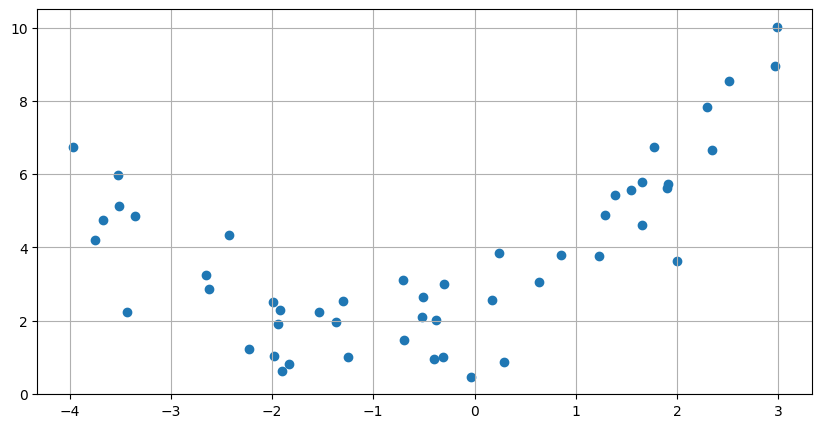

In [5]:
fig = plt.figure(figsize=(10, 5))
plt.scatter(df.x, df.y)
plt.grid()

Remarque: La relation y(x) est non linéaire, nous allons utiliser le modèle de régression polynomiale pour la reprénseter. Il faut tout d'abord construire les emsembles de données train et test 

5. Définir x et y, ensuite séparer en train et test (test_size =0.2)

Vérifier ensuite le pourcentage de la séparation 

In [6]:
x = df.x
y = df.y
from sklearn.model_selection import train_test_split
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

#On sépare les données en entrainement et test (80% de données d'entrainement et 20% de test pour la fin)
#X_train, X_test, Y_train, Y_test = train_test_split(X_partial_np, Y_partial_np, test_size = 0.2)
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size =0.3)

In [7]:
X_test.shape[0]
#X_test

15

In [8]:
# Mettre X_train et Y_train sous forme de liste.values.reshape(-1,1), un array d'une colonne et ? lignes

x_train=X_train.values.reshape(-1,1)
y_train=Y_train.values.reshape(-1,1)
x_test=X_test.values.reshape(-1,1)
y_test=Y_test.values.reshape(-1,1)
x_test

array([[-3.35485755],
       [-2.65471557],
       [-3.97060402],
       [ 0.63795552],
       [-0.29709542],
       [-0.38432289],
       [-0.70417416],
       [-2.22565159],
       [-1.25432889],
       [-3.50849663],
       [ 1.90987667],
       [-2.42266513],
       [-1.98413408],
       [ 0.28719156],
       [-0.40448955]])

6. Représenter sur un même graphique les nuages de points de l'ensemble d'entraînement et de test, en utilisant des couleurs distinctes.

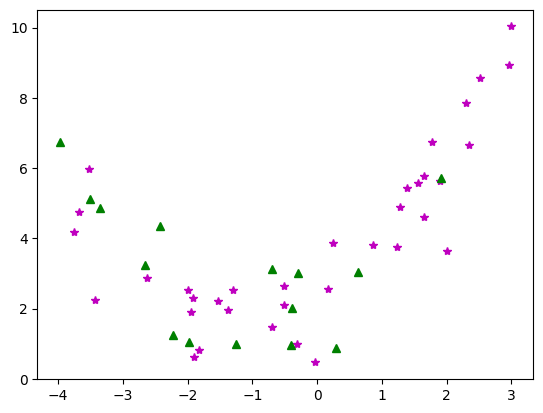

In [9]:
plt.plot(x_train,y_train,'*',c="m")
plt.plot(x_test,y_test,'^',c="g")

7. De quel degré doit être le polynôme pour bien représenter y(x) ?

Créer ce polynôme avec PolynomialFeatures de ScikitLearn https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html

In [10]:
from sklearn.preprocessing import PolynomialFeatures
# from sklearn.metrics import mean_squared_error, r2_score

In [11]:
# préparation du modèle
nb_degree=2
polynomial_features= PolynomialFeatures(degree=3)#,include_bias=False)

8. Créer les nouvelles variables "indépendantes" à partir de x_train et le polynôme de la question 7 (utiliser "fit_transform")

Créer un modèle de régression linéaire https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

Entrainer le modèle.


In [12]:
model = LinearRegression()

# analyse des données d'entrainement

Xtrain_poly = polynomial_features.fit_transform(x_train)  # Cela permet de calculer (x_train)^0  (x_train)^1  (x_train)^2, ...
model.fit(Xtrain_poly, y_train)


LinearRegression()

9. Faire la prédiction pour les ensembles de train et test.

Pour chaque ensemble de données, affichier le score et l'erreur RMSE 

In [13]:

# prédire les valeurs d'entrainement
Ytrain_pred = model.predict(Xtrain_poly)

# calculate RMSE et score
rmse = np.sqrt(mean_squared_error(y_train,Ytrain_pred))
r2 = r2_score(y_train,Ytrain_pred)

print('RMSE: ', rmse)
print('R2: ', r2)

RMSE:  0.9226970518108566
R2:  0.8562850684225116


In [14]:
ytest = Ytrain_pred.flatten()

In [15]:
print(ytest.shape)

(35,)


In [16]:
# analyse des données test
Xtest_poly = polynomial_features.fit_transform(x_test)  

# prédire les valeurs de test
Ytest_pred = model.predict(Xtest_poly)

# calculate RMSE et score
rmse = np.sqrt(mean_squared_error(y_test,Ytest_pred))
r2 = r2_score(y_test,Ytest_pred)

print('RMSE: ', rmse)
print('R2: ', r2)

RMSE:  1.0903994256126814
R2:  0.6549138253250466


10. Afficher les coefficients du modèle de régression: intercept_ et coef_

In [17]:
print('coef =',model.coef_)

print('intercept =',model.intercept_)

coef = [[ 0.          1.07816089  0.44899404 -0.00171356]]
intercept = [2.30354924]


12. Visualiser graphiquement le polynôme du modèle de régression polynomiale.

Mettre sur le même graphique le nuage de point de la base de données y(x).

In [18]:
# tracer le polynôme:

x_new_min = -4
x_new_max =3

X_NEW = np.linspace(x_new_min, x_new_max, 100)
X_NEW = X_NEW[:,np.newaxis]     #  transforme en array

X_NEW_TRANSF = polynomial_features.fit_transform(X_NEW)

Y_NEW = model.predict(X_NEW_TRANSF)



Text(0, 0.5, 'y')

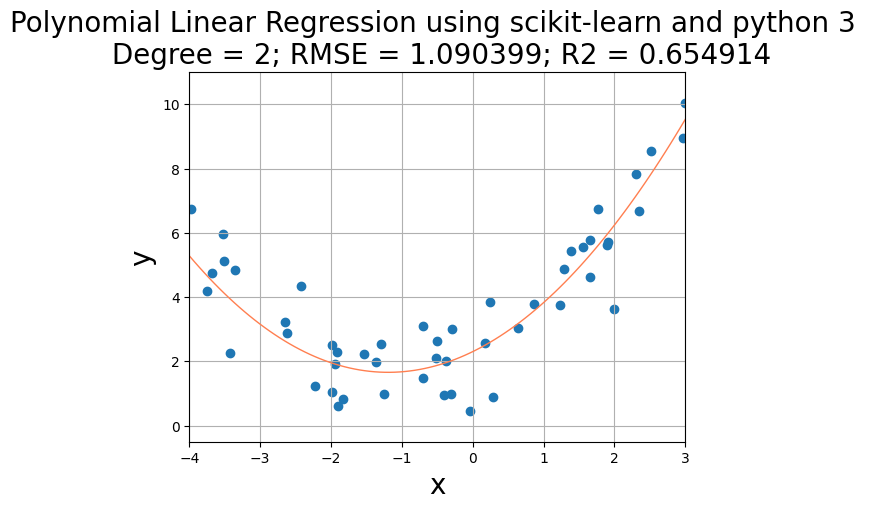

In [19]:
plt.plot(X_NEW, Y_NEW, color='coral', linewidth=1)
plt.scatter(x,y)

plt.grid()
plt.xlim(x_new_min,x_new_max)
plt.ylim(-0.5,11)

title = 'Degree = {}; RMSE = {}; R2 = {}'.format(nb_degree, round(rmse,6), round(r2,6))

plt.title("Polynomial Linear Regression using scikit-learn and python 3 \n " + title,
          fontsize=20)
plt.xlabel('x',fontsize=20)
plt.ylabel('y',fontsize=20)

#plt.savefig("polynomial_linear_regression.png", bbox_inches='tight')
#plt.show()

13. Pourquoi le modèle de "régression linéaire" peut être utilisé pour faire la régression polynomiale?

Votre réponse:

14. Comparer les performances (RMSE et R2 sur les 2 ensembles train et test) avec 3 degrés suivants du polynôme: n = 1, n = 2 et n = 5.

Que remarquez-vous?

Votre réponse:

In [20]:
# préparation du modèle
nb_degree=1
polynomial_features= PolynomialFeatures(degree=nb_degree,include_bias=False)

model = LinearRegression()

# analyse des données d'entrainement

Xtrain_poly = polynomial_features.fit_transform(x_train)  # Cela permet de calculer (x_train)^0  (x_train)^1  (x_train)^2, ...
model.fit(Xtrain_poly, y_train)

# prédire les valeurs d'entrainement
Ytrain_pred = model.predict(Xtrain_poly)

# calculate RMSE et score
rmse = np.sqrt(mean_squared_error(y_train,Ytrain_pred))
r2 = r2_score(y_train,Ytrain_pred)

print('RMSE train: ', rmse)
print('R train: ', r2)

# analyse des données test
Xtest_poly = polynomial_features.fit_transform(x_test)  

# prédire les valeurs de test
Ytest_pred = model.predict(Xtest_poly)

# calculate RMSE et score
rmse = np.sqrt(mean_squared_error(y_test,Ytest_pred))
r2 = r2_score(y_test,Ytest_pred)

print('RMSE test: ', rmse)
print('R2 test: ', r2)

RMSE train:  1.8929800601048157
R train:  0.39511097455139943
RMSE test:  2.5392647374365875
R2 test:  -0.8714244345620619


In [21]:
# préparation du modèle
nb_degree=2
polynomial_features= PolynomialFeatures(degree=nb_degree,include_bias=False)

model = LinearRegression()

# analyse des données d'entrainement

Xtrain_poly = polynomial_features.fit_transform(x_train)  # Cela permet de calculer (x_train)^0  (x_train)^1  (x_train)^2, ...
model.fit(Xtrain_poly, y_train)

# prédire les valeurs d'entrainement
Ytrain_pred = model.predict(Xtrain_poly)

# calculate RMSE et score
rmse = np.sqrt(mean_squared_error(y_train,Ytrain_pred))
r2 = r2_score(y_train,Ytrain_pred)

print('RMSE train: ', rmse)
print('R train: ', r2)

# analyse des données test
Xtest_poly = polynomial_features.fit_transform(x_test)  

# prédire les valeurs de test
Ytest_pred = model.predict(Xtest_poly)

# calculate RMSE et score
rmse = np.sqrt(mean_squared_error(y_test,Ytest_pred))
r2 = r2_score(y_test,Ytest_pred)

print('RMSE test: ', rmse)
print('R2 test: ', r2)

RMSE train:  0.9227724454574284
R train:  0.8562615815469237
RMSE test:  1.0927115042737625
R2 test:  0.6534488350502731


In [22]:
# préparation du modèle
nb_degree=15
polynomial_features= PolynomialFeatures(degree=nb_degree,include_bias=False)

model = LinearRegression()

# analyse des données d'entrainement

Xtrain_poly = polynomial_features.fit_transform(x_train)  # Cela permet de calculer (x_train)^0  (x_train)^1  (x_train)^2, ...
model.fit(Xtrain_poly, y_train)

# prédire les valeurs d'entrainement
Ytrain_pred = model.predict(Xtrain_poly)

# calculate RMSE et score
rmse = np.sqrt(mean_squared_error(y_train,Ytrain_pred))
r2 = r2_score(y_train,Ytrain_pred)

print('RMSE train: ', rmse)
print('R train: ', r2)

# analyse des données test
Xtest_poly = polynomial_features.fit_transform(x_test)  

# prédire les valeurs de test
Ytest_pred = model.predict(Xtest_poly)

# calculate RMSE et score
rmse = np.sqrt(mean_squared_error(y_test,Ytest_pred))
r2 = r2_score(y_test,Ytest_pred)

print('RMSE test: ', rmse)
print('R2 test: ', r2)

RMSE train:  0.6594164194901796
R train:  0.9265988033349637
RMSE test:  25.138628970792496
R2 test:  -182.41696734845135


Text(0, 0.5, 'y')

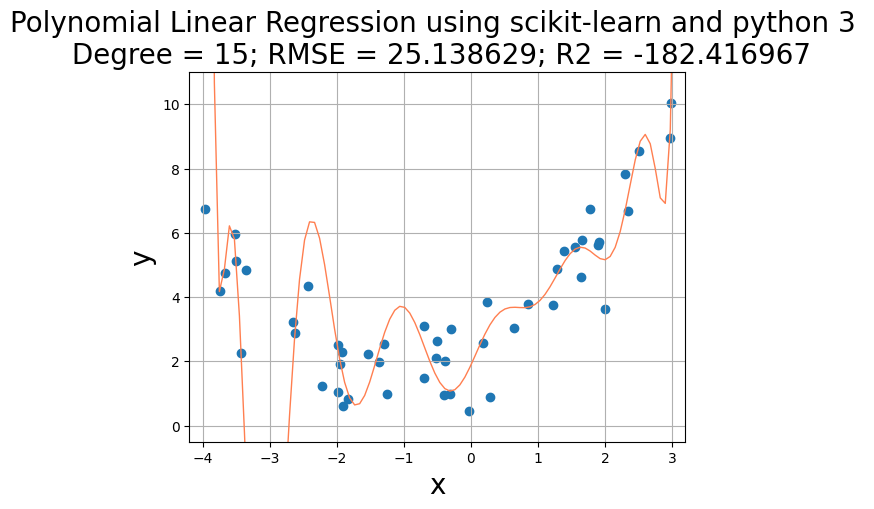

In [23]:
# tracer le polynôme:

x_new_min = -4.2
x_new_max =3.2

X_NEW = np.linspace(x_new_min, x_new_max, 100)
X_NEW = X_NEW[:,np.newaxis]     #  transforme en array

X_NEW_TRANSF = polynomial_features.fit_transform(X_NEW)

Y_NEW = model.predict(X_NEW_TRANSF)

plt.plot(X_NEW, Y_NEW, color='coral', linewidth=1)
plt.scatter(x,y)

plt.grid()
plt.xlim(x_new_min,x_new_max)
plt.ylim(-0.5,11)

title = 'Degree = {}; RMSE = {}; R2 = {}'.format(nb_degree, round(rmse,6), round(r2,6))

plt.title("Polynomial Linear Regression using scikit-learn and python 3 \n " + title,
          fontsize=20)
plt.xlabel('x',fontsize=20)
plt.ylabel('y',fontsize=20)